# ABC untuk Optimasi Random Forest

Notebook generik untuk forecasting Remaining Useful Life (RUL) menggunakan Random Forest yang dioptimasi dengan Artificial Bee Colony (ABC). Konfigurasi awal menggunakan dataset PT Amanah, tetapi seluruh fungsi dapat digunakan kembali untuk dataset lain.

Alur notebook: konfigurasi → pemuatan dan validasi data → pembentukan target → split acak → optimasi ABC → evaluasi → penyimpanan artefak.


## 1. Import dan konfigurasi dasar


In [1]:
import json
import re
import time
from copy import deepcopy
from pathlib import Path
from typing import Any

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split


In [2]:
def find_root() -> Path:
    """Menemukan root proyek dari lokasi kerja notebook."""
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "datas").is_dir() and (path / "newcode").is_dir():
            return path
    raise FileNotFoundError("Root proyek dengan folder datas/ dan newcode/ tidak ditemukan")


ROOT = find_root()

FEATURES = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]

PARAM_KEYS = [
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
    "max_features",
]

INT_PARAMS = {
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf",
}

DEFAULT_CFG: dict[str, Any] = {
    "data": "",
    "output": "newcode/artifacts",
    "run_name": "abc_random_forest",
    "sheet": 0,
    "features": FEATURES,
    "target": {
        "column": "sisa jam",
        "lifetime_column": "Unit Lifetime (Hour)",
        "status_column": "Status",
        "train_status": ["critical"],
        "break_status": "break",
        "failure_hour": None,
        "max_rul": None,
    },
    "split": {"test_size": 0.2, "cv": 5, "shuffle": True},
    "abc": {
        "food_number": 15,
        "limit": 5,
        "max_iter": 30,
        "patience": 8,
    },
    "bounds": {
        "n_estimators": [50, 300],
        "max_depth": [2, 30],
        "min_samples_split": [2, 20],
        "min_samples_leaf": [1, 20],
        "max_features": [0.1, 1.0],
    },
    "seed": 42,
    "n_jobs": -1,
}


## 2. Konfigurasi eksperimen

Ubah cell berikut untuk memakai dataset atau parameter eksperimen lain. Jika target belum tersedia, isi `failure_hour` atau sediakan satu baris dengan status `Break`.


In [3]:
cfg = deepcopy(DEFAULT_CFG)
cfg["data"] = "datas/Data_PT.Amanah_Critical_Break.xlsx"
cfg["output"] = "newcode/artifacts"
cfg["run_name"] = "abc_pt_amanah_random"
cfg["sheet"] = "Sheet1"
cfg["target"]["train_status"] = ["critical"]
cfg["target"]["break_status"] = "break"
cfg["target"]["failure_hour"] = None
cfg["target"]["max_rul"] = 2550
cfg["split"] = {"test_size": 0.2, "cv": 5, "shuffle": True}
cfg["abc"] = {
    "food_number": 15,
    "limit": 5,
    "max_iter": 30,
    "patience": 8,
}
cfg["seed"] = 42
cfg["n_jobs"] = -1

cfg


{'data': 'datas/Data_PT.Amanah_Critical_Break.xlsx',
 'output': 'newcode/artifacts',
 'run_name': 'abc_pt_amanah_random',
 'sheet': 'Sheet1',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'target': {'column': 'sisa jam',
  'lifetime_column': 'Unit Lifetime (Hour)',
  'status_column': 'Status',
  'train_status': ['critical'],
  'break_status': 'break',
  'failure_hour': None,
  'max_rul': 2550},
 'split': {'test_size': 0.2, 'cv': 5, 'shuffle': True},
 'abc': {'food_number': 15, 'limit': 5, 'max_iter': 30, 'patience': 8},
 'bounds': {'n_estimators': [50, 300],
  'max_depth': [2, 30],
  'min_samples_split': [2, 20],
  'min_samples_leaf': [1, 20],
  'max_features': [0.1, 1.0]},
 'seed': 42,
 'n_jobs': -1}

## 3. Fungsi pemuatan dan validasi data


In [4]:
def merge_cfg(base: dict[str, Any], extra: dict[str, Any]) -> dict[str, Any]:
    """Menggabungkan konfigurasi bertingkat tanpa mengubah nilai asal."""
    out = deepcopy(base)
    for key, val in extra.items():
        if isinstance(val, dict) and isinstance(out.get(key), dict):
            out[key] = merge_cfg(out[key], val)
        else:
            out[key] = val
    return out


def abs_path(val: str | Path) -> Path:
    """Mengubah path relatif menjadi path dari root proyek."""
    path = Path(val)
    return path if path.is_absolute() else ROOT / path


def norm_col(val: str) -> str:
    """Menormalkan nama kolom tanpa menghilangkan makna sensor."""
    text = re.sub(r"\s+", " ", str(val).strip()).casefold()
    return text.replace(" (°c)", "")


def col_map(df: pd.DataFrame) -> dict[str, str]:
    """Membuat peta nama kolom ternormalisasi ke nama aktual."""
    out: dict[str, str] = {}
    for col in df.columns:
        key = norm_col(col)
        if key in out:
            raise ValueError(f"Nama kolom menjadi ambigu setelah normalisasi: {col}")
        out[key] = str(col)
    return out


def find_col(cols: dict[str, str], name: str, required: bool = True) -> str | None:
    """Mencari nama kolom dengan toleransi kapitalisasi dan satuan °C."""
    col = cols.get(norm_col(name))
    if col is None and required:
        raise ValueError(f"Kolom wajib tidak ditemukan: {name}")
    return col


def load_table(path: Path, sheet: str | int = 0) -> pd.DataFrame:
    """Memuat satu dataset Excel atau CSV."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset tidak ditemukan: {path}")
    if path.suffix.casefold() in {".xlsx", ".xls"}:
        return pd.read_excel(path, sheet_name=sheet)
    if path.suffix.casefold() == ".csv":
        return pd.read_csv(path)
    raise ValueError("Format dataset harus .xlsx, .xls, atau .csv")


In [5]:
def prep_data(
    raw: pd.DataFrame, cfg: dict[str, Any]
) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Memvalidasi skema, membersihkan data, dan membentuk target RUL."""
    target = cfg["target"]
    cols = col_map(raw)
    feat_src = [find_col(cols, name) for name in cfg["features"]]
    life_src = find_col(cols, target["lifetime_column"])
    status_src = find_col(cols, target["status_column"])
    target_src = find_col(cols, target["column"], required=False)

    data = pd.DataFrame(index=raw.index)
    for name, src in zip(cfg["features"], feat_src, strict=True):
        data[name] = pd.to_numeric(raw[src], errors="coerce")
    data["_lifetime"] = pd.to_numeric(raw[life_src], errors="coerce")
    data["_status"] = raw[status_src].astype("string").str.strip().str.casefold()

    if target_src is not None:
        data["_target"] = pd.to_numeric(raw[target_src], errors="coerce")

    need = [*cfg["features"], "_lifetime", "_status"]
    before = len(data)
    data = data.dropna(subset=need).copy()
    dropped = before - len(data)
    data = data.sort_values("_lifetime", kind="stable").reset_index(drop=True)

    fail_hour = target.get("failure_hour")
    target_mode = "existing"
    if target_src is not None:
        data = data.dropna(subset=["_target"]).copy()
    else:
        target_mode = "derived"
        if fail_hour is None:
            break_status = str(target["break_status"]).strip().casefold()
            break_hours = data.loc[
                data["_status"] == break_status, "_lifetime"
            ].unique()
            if len(break_hours) != 1:
                raise ValueError(
                    "Target tidak tersedia dan failure hour tidak dapat ditentukan "
                    "secara tunggal. Isi target.failure_hour pada konfigurasi."
                )
            fail_hour = float(break_hours[0])

        data["_target"] = float(fail_hour) - data["_lifetime"]
        data["_target"] = data["_target"].clip(lower=0)
        max_rul = target.get("max_rul")
        if max_rul is not None:
            data["_target"] = data["_target"].clip(upper=float(max_rul))

    statuses = [str(val).strip().casefold() for val in target["train_status"]]
    if statuses:
        data = data[data["_status"].isin(statuses)].copy()
    if data.empty:
        raise ValueError("Tidak ada data tersisa setelah filter status training")

    data = data.reset_index(drop=True)
    meta = {
        "raw_rows": int(len(raw)),
        "clean_rows": int(len(data)),
        "dropped_invalid_rows": int(dropped),
        "target_mode": target_mode,
        "failure_hour": None if fail_hour is None else float(fail_hour),
        "target_min": float(data["_target"].min()),
        "target_max": float(data["_target"].max()),
        "lifetime_min": float(data["_lifetime"].min()),
        "lifetime_max": float(data["_lifetime"].max()),
        "train_status": statuses,
    }
    return data, meta


def validate_cfg(cfg: dict[str, Any]) -> None:
    """Memastikan konfigurasi aman digunakan sebelum proses training."""
    if not cfg["data"]:
        raise ValueError("Path dataset wajib diisi melalui konfigurasi atau --data")
    if not 0 < float(cfg["split"]["test_size"]) < 1:
        raise ValueError("split.test_size harus berada di antara 0 dan 1")
    if int(cfg["split"]["cv"]) < 2:
        raise ValueError("split.cv minimal 2")
    if int(cfg["abc"]["food_number"]) < 2:
        raise ValueError("abc.food_number minimal 2")
    for key in PARAM_KEYS:
        if key not in cfg["bounds"]:
            raise ValueError(f"Batas hyperparameter belum tersedia: {key}")
        low, high = cfg["bounds"][key]
        if float(low) >= float(high):
            raise ValueError(f"Batas hyperparameter tidak valid: {key}")


## 4. Membaca dan memeriksa data

Baris tidak valid, termasuk header duplikat di tengah/akhir file, dibuang melalui validasi numerik. Target PT Amanah diturunkan dari lifetime pada status `Break` dan dibatasi maksimum 2.550 jam.


In [6]:
validate_cfg(cfg)

data_path = abs_path(cfg["data"])
raw = load_table(data_path, cfg["sheet"])
data, meta = prep_data(raw, cfg)

print("Metadata data:")
print(json.dumps(meta, ensure_ascii=False, indent=2))
print("\nLima baris awal data training:")
display(data.head())


Metadata data:
{
  "raw_rows": 2569,
  "clean_rows": 720,
  "dropped_invalid_rows": 1,
  "target_mode": "derived",
  "failure_hour": 78637.0,
  "target_min": 1.0,
  "target_max": 2524.0,
  "lifetime_min": 76113.0,
  "lifetime_max": 78636.0,
  "train_status": [
    "critical"
  ]
}

Lima baris awal data training:


,Exhaust Gas Temperature LF (Left Front),Exhaust Gas Temperature LR (Left Rear),Exhaust Gas Temperature RF (Right Front),Exhaust Gas Temperature RR (Right Rear),Blowby Pressure (Kpa),Boost Pressure (Kpa),Engine Oil Temp (°C),Coolant Temp (°C),_lifetime,_status,_target
0,750.0,667.933,608.661,714.650,2.000,164.638,117.389,101.043,76113.0,critical,2524.0
1,750.0,672.928,603.948,732.865,2.000,165.350,118.467,101.184,76116.0,critical,2521.0
2,750.0,671.021,601.956,750.000,2.027,165.125,119.946,100.432,76117.0,critical,2520.0
3,750.0,663.827,600.000,750.000,2.385,166.053,119.871,99.864,76118.0,critical,2519.0
4,750.0,669.326,600.000,748.715,2.579,166.539,118.118,98.967,76119.0,critical,2518.0


In [7]:
print("Informasi data:")
data[[*cfg["features"], "_lifetime", "_status", "_target"]].info()

print("\nKorelasi fitur terhadap target RUL:")
corr = data[[*cfg["features"], "_target"]].corr(numeric_only=True)
display(corr[["_target"]].sort_values("_target"))


Informasi data:
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Exhaust Gas Temperature LF (Left Front)   720 non-null    float64
 1   Exhaust Gas Temperature LR (Left Rear)    720 non-null    float64
 2   Exhaust Gas Temperature RF (Right Front)  720 non-null    float64
 3   Exhaust Gas Temperature RR (Right Rear)   720 non-null    float64
 4   Blowby Pressure (Kpa)                     720 non-null    float64
 5   Boost Pressure (Kpa)                      720 non-null    float64
 6   Engine Oil Temp (°C)                      720 non-null    float64
 7   Coolant Temp (°C)                         720 non-null    float64
 8   _lifetime                                 720 non-null    float64
 9   _status                                   720 non-null    string 
 10  _target                          

,_target
Blowby Pressure (Kpa),-0.622522
Coolant Temp (°C),-0.317685
Exhaust Gas Temperature RF (Right Front),-0.267345
Exhaust Gas Temperature RR (Right Rear),-0.209086
Engine Oil Temp (°C),-0.194732
Exhaust Gas Temperature LF (Left Front),-0.141277
Exhaust Gas Temperature LR (Left Rear),-0.096684
Boost Pressure (Kpa),0.474707
_target,1.000000


## 5. Split acak

Data dibagi secara acak karena observasi pada dataset diperoleh secara acak. Seed tetap digunakan agar pembagian dapat direproduksi.


In [8]:
def split_data(
    data: pd.DataFrame, cfg: dict[str, Any]
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Membagi data secara acak dengan seed yang dapat direproduksi."""
    train_df, test_df = train_test_split(
        data,
        test_size=float(cfg["split"]["test_size"]),
        random_state=int(cfg["seed"]),
        shuffle=bool(cfg["split"]["shuffle"]),
    )
    if len(train_df) <= int(cfg["split"]["cv"]):
        raise ValueError("Data terlalu sedikit untuk split test dan cross-validation")
    return train_df.sort_index().copy(), test_df.sort_index().copy()


def metric_values(actual: pd.Series, pred: np.ndarray) -> dict[str, float]:
    """Menghitung metrik regresi utama."""
    mse = float(mean_squared_error(actual, pred))
    return {
        "mse": mse,
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(actual, pred)),
        "r2": float(r2_score(actual, pred)),
    }


In [9]:
train_df, test_df = split_data(data, cfg)
features = list(cfg["features"])

x_train = train_df[features]
y_train = train_df["_target"]
x_test = test_df[features]
y_test = test_df["_target"]

print(f"Baris training: {len(train_df)}")
print(f"Baris test: {len(test_df)}")
print(
    "Rentang lifetime training:",
    train_df["_lifetime"].min(),
    "-",
    train_df["_lifetime"].max(),
)
print(
    "Rentang lifetime test:",
    test_df["_lifetime"].min(),
    "-",
    test_df["_lifetime"].max(),
)


Baris training: 576
Baris test: 144
Rentang lifetime training: 76113.0 - 78636.0
Rentang lifetime test: 76117.0 - 78633.0


## 6. Implementasi Artificial Bee Colony

Ruang pencarian mengikuti oldcode: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, dan `max_features`. Fungsi objektif memakai MSE dari K-fold acak dengan seed tetap.


In [10]:
def decode(sol: np.ndarray, cfg: dict[str, Any]) -> dict[str, int | float]:
    """Mengubah posisi kontinu ABC menjadi hyperparameter Random Forest."""
    out: dict[str, int | float] = {}
    for idx, key in enumerate(PARAM_KEYS):
        low, high = cfg["bounds"][key]
        val = float(np.clip(sol[idx], low, high))
        out[key] = int(round(val)) if key in INT_PARAMS else val
    return out


def param_key(params: dict[str, int | float]) -> tuple[int | float, ...]:
    """Membentuk kunci cache dari satu konfigurasi model."""
    return tuple(
        int(params[key]) if key in INT_PARAMS else round(float(params[key]), 8)
        for key in PARAM_KEYS
    )


class Objective:
    """Fungsi objektif MSE dengan cache untuk konfigurasi berulang."""

    def __init__(self, x: pd.DataFrame, y: pd.Series, cfg: dict[str, Any]):
        self.x = x
        self.y = y
        self.cfg = cfg
        folds = min(int(cfg["split"]["cv"]), len(x) - 1)
        if folds < 2:
            raise ValueError("Data training tidak cukup untuk KFold")
        self.cv = KFold(
            n_splits=folds,
            shuffle=bool(cfg["split"]["shuffle"]),
            random_state=int(cfg["seed"]),
        )
        self.cache: dict[tuple[int | float, ...], float] = {}

    def __call__(self, sol: np.ndarray) -> float:
        params = decode(sol, self.cfg)
        key = param_key(params)
        if key not in self.cache:
            model = RandomForestRegressor(
                **params,
                random_state=int(self.cfg["seed"]),
                n_jobs=int(self.cfg["n_jobs"]),
            )
            scores = cross_val_score(
                model,
                self.x,
                self.y,
                cv=self.cv,
                scoring="neg_mean_squared_error",
                n_jobs=int(self.cfg["n_jobs"]),
                error_score="raise",
            )
            self.cache[key] = float(-scores.mean())
        return self.cache[key]


In [11]:
def neighbor(
    pop: np.ndarray,
    idx: int,
    low: np.ndarray,
    high: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """Membentuk kandidat tetangga dengan mengubah satu dimensi."""
    choices = np.delete(np.arange(len(pop)), idx)
    other = int(rng.choice(choices))
    dim = int(rng.integers(pop.shape[1]))
    phi = float(rng.uniform(-1.0, 1.0))
    cand = pop[idx].copy()
    cand[dim] += phi * (pop[idx, dim] - pop[other, dim])
    return np.clip(cand, low, high)


def run_abc(
    obj: Objective, cfg: dict[str, Any]
) -> tuple[dict[str, int | float], float, list[float], int]:
    """Menjalankan employed, onlooker, dan scout bee secara deterministik."""
    abc = cfg["abc"]
    food = int(abc["food_number"])
    limit = int(abc["limit"])
    max_iter = int(abc["max_iter"])
    patience = int(abc["patience"])
    rng = np.random.default_rng(int(cfg["seed"]))

    bounds = np.asarray([cfg["bounds"][key] for key in PARAM_KEYS], dtype=float)
    low, high = bounds[:, 0], bounds[:, 1]
    pop = rng.uniform(low, high, size=(food, len(PARAM_KEYS)))
    scores = np.asarray([obj(sol) for sol in pop], dtype=float)
    trials = np.zeros(food, dtype=int)

    best_idx = int(np.argmin(scores))
    best_sol = pop[best_idx].copy()
    best_score = float(scores[best_idx])
    curve = [best_score]
    stale = 0

    for epoch in range(1, max_iter + 1):
        # Fase employed bee.
        for idx in range(food):
            cand = neighbor(pop, idx, low, high, rng)
            score = obj(cand)
            if score < scores[idx]:
                pop[idx], scores[idx], trials[idx] = cand, score, 0
            else:
                trials[idx] += 1

        # Fase onlooker bee.
        fit = 1.0 / (1.0 + np.maximum(scores, 0.0))
        probs = fit / fit.sum() if fit.sum() > 0 else np.full(food, 1 / food)
        for _ in range(food):
            idx = int(rng.choice(food, p=probs))
            cand = neighbor(pop, idx, low, high, rng)
            score = obj(cand)
            if score < scores[idx]:
                pop[idx], scores[idx], trials[idx] = cand, score, 0
            else:
                trials[idx] += 1

        # Fase scout bee.
        for idx in np.flatnonzero(trials >= limit):
            pop[idx] = rng.uniform(low, high)
            scores[idx] = obj(pop[idx])
            trials[idx] = 0

        idx = int(np.argmin(scores))
        score = float(scores[idx])
        if score < best_score:
            best_sol, best_score, stale = pop[idx].copy(), score, 0
        else:
            stale += 1
        curve.append(best_score)
        print(f"Iterasi {epoch}/{max_iter} | MSE CV terbaik: {best_score:.6f}")

        if patience > 0 and stale >= patience:
            print(f"Optimasi dihentikan dini setelah {stale} iterasi tanpa perbaikan.")
            break

    return decode(best_sol, cfg), best_score, curve, len(obj.cache)


## 7. Menjalankan optimasi ABC


In [12]:
started = time.perf_counter()
obj = Objective(x_train, y_train, cfg)

best_params, cv_mse, curve, evals = run_abc(obj, cfg)
cv_rmse = float(np.sqrt(cv_mse))

print("\nHyperparameter terbaik:")
print(json.dumps(best_params, indent=2))
print(f"CV MSE: {cv_mse:.6f}")
print(f"CV RMSE: {cv_rmse:.6f}")
print(f"Evaluasi objektif unik: {evals}")


Iterasi 1/30 | MSE CV terbaik: 56921.110918
Iterasi 2/30 | MSE CV terbaik: 44049.543599
Iterasi 3/30 | MSE CV terbaik: 43149.430776
Iterasi 4/30 | MSE CV terbaik: 43149.430776
Iterasi 5/30 | MSE CV terbaik: 43149.430776
Iterasi 6/30 | MSE CV terbaik: 43149.430776
Iterasi 7/30 | MSE CV terbaik: 43149.430776
Iterasi 8/30 | MSE CV terbaik: 42944.026470
Iterasi 9/30 | MSE CV terbaik: 41984.356544
Iterasi 10/30 | MSE CV terbaik: 41678.462439
Iterasi 11/30 | MSE CV terbaik: 41528.813964
Iterasi 12/30 | MSE CV terbaik: 41528.813964
Iterasi 13/30 | MSE CV terbaik: 41447.118619
Iterasi 14/30 | MSE CV terbaik: 41447.118619
Iterasi 15/30 | MSE CV terbaik: 41447.118619
Iterasi 16/30 | MSE CV terbaik: 41447.118619
Iterasi 17/30 | MSE CV terbaik: 41447.118619
Iterasi 18/30 | MSE CV terbaik: 41447.118619
Iterasi 19/30 | MSE CV terbaik: 41447.118619
Iterasi 20/30 | MSE CV terbaik: 41447.118619
Iterasi 21/30 | MSE CV terbaik: 41447.118619
Optimasi dihentikan dini setelah 8 iterasi tanpa perbaikan.

Hyp

## 8. Melatih dan mengevaluasi model final


In [13]:
model = RandomForestRegressor(
    **best_params,
    random_state=int(cfg["seed"]),
    n_jobs=int(cfg["n_jobs"]),
)
model.fit(x_train, y_train)
pred = model.predict(x_test)
metrics = metric_values(y_test, pred)

print("Metrik test acak:")
print(json.dumps(metrics, indent=2))


Metrik test acak:
{
  "mse": 55487.7614886211,
  "rmse": 235.55840356187912,
  "mae": 123.17628316100678,
  "r2": 0.9128111025640975
}


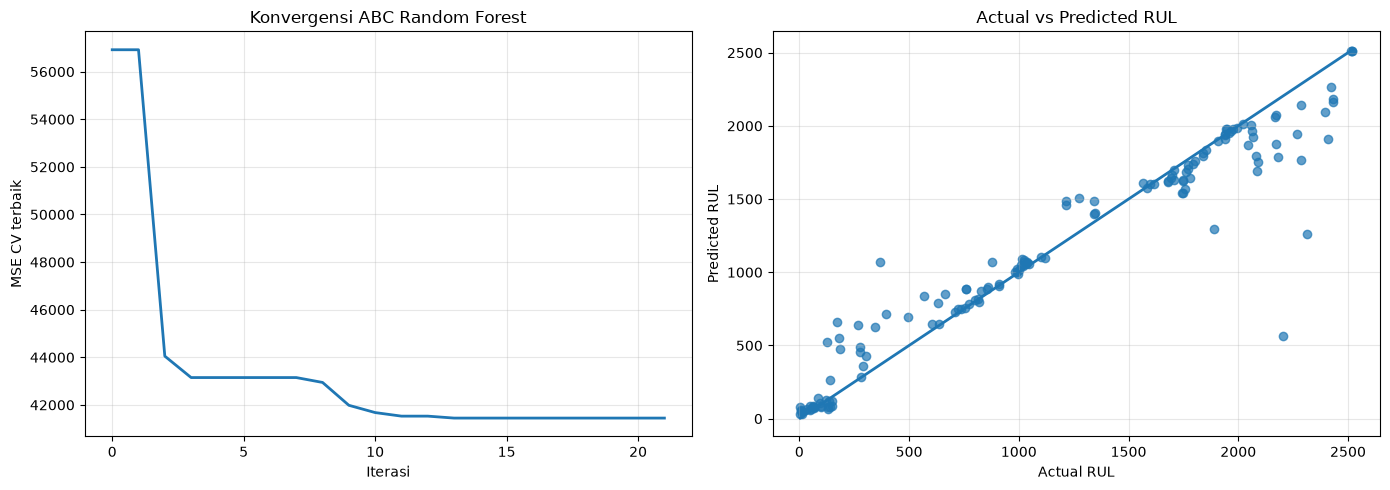

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(curve)), curve, linewidth=2)
axes[0].set(
    title="Konvergensi ABC Random Forest",
    xlabel="Iterasi",
    ylabel="MSE CV terbaik",
)
axes[0].grid(True, alpha=0.3)

low = float(min(y_test.min(), pred.min()))
high = float(max(y_test.max(), pred.max()))
axes[1].scatter(y_test, pred, alpha=0.7)
axes[1].plot([low, high], [low, high], linewidth=2)
axes[1].set(
    title="Actual vs Predicted RUL",
    xlabel="Actual RUL",
    ylabel="Predicted RUL",
)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Menyimpan artefak

Artefak berisi model, metadata, parameter terbaik, metrik, prediksi test, kurva konvergensi, dan grafik.


In [15]:
def json_ready(val: Any) -> Any:
    """Mengubah nilai NumPy dan Path agar dapat ditulis ke JSON."""
    if isinstance(val, dict):
        return {str(key): json_ready(item) for key, item in val.items()}
    if isinstance(val, (list, tuple)):
        return [json_ready(item) for item in val]
    if isinstance(val, Path):
        return str(val)
    if isinstance(val, np.generic):
        return val.item()
    return val


def save_plot(curve: list[float], actual: pd.Series, pred: np.ndarray, out: Path) -> None:
    """Menyimpan kurva konvergensi dan grafik actual-predicted."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(len(curve)), curve, linewidth=2)
    ax.set(title="Konvergensi ABC Random Forest", xlabel="Iterasi", ylabel="MSE CV terbaik")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out / "convergence.png", dpi=160)
    plt.close(fig)

    low = float(min(actual.min(), pred.min()))
    high = float(max(actual.max(), pred.max()))
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(actual, pred, alpha=0.7)
    ax.plot([low, high], [low, high], linewidth=2)
    ax.set(title="Actual vs Predicted RUL", xlabel="Actual RUL", ylabel="Predicted RUL")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(out / "actual_vs_predicted.png", dpi=160)
    plt.close(fig)


In [16]:
out = abs_path(cfg["output"]) / str(cfg["run_name"])
out.mkdir(parents=True, exist_ok=True)

pred_df = test_df[["_lifetime", "_status", "_target"]].copy()
pred_df.columns = ["lifetime", "status", "actual_rul"]
pred_df["predicted_rul"] = pred
pred_df["error"] = pred_df["predicted_rul"] - pred_df["actual_rul"]
pred_df.to_csv(out / "test_predictions.csv", index=False)

model_data = {
    "model": model,
    "features": features,
    "params": best_params,
    "target": cfg["target"],
    "seed": cfg["seed"],
}
joblib.dump(model_data, out / "model.joblib")

result = {
    "run_name": cfg["run_name"],
    "data": str(data_path),
    "data_meta": meta,
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "best_params": best_params,
    "cv_mse": cv_mse,
    "cv_rmse": cv_rmse,
    "test_metrics": metrics,
    "objective_evaluations": evals,
    "iterations": len(curve) - 1,
    "elapsed_seconds": time.perf_counter() - started,
    "feature_importance": dict(
        zip(features, model.feature_importances_, strict=True)
    ),
    "config": cfg,
}
(out / "metrics.json").write_text(
    json.dumps(json_ready(result), ensure_ascii=False, indent=2),
    encoding="utf-8",
)
(out / "convergence.json").write_text(
    json.dumps(curve, indent=2),
    encoding="utf-8",
)
save_plot(curve, y_test, pred, out)

print(f"Seluruh artefak disimpan di: {out}")


Seluruh artefak disimpan di: /home/khai/work/cls/vehicle-health/newcode/artifacts/abc_pt_amanah_random
